Connected to .venv (3.12.0) (Python 3.12.0)

 # Fase 4 — Apresentação Crítica dos Resultados
 **TechChallenger3 — Previsão de Atrasos de Voos (EUA)**

 Consolidação do pipeline completo: EDA → Supervisionado → Não Supervisionado → Conclusões

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path

_ROOT  = Path(__file__).resolve().parent.parent
FIGS   = _ROOT / "outputs" / "figures"
OUT    = _ROOT / "outputs"

plt.rcParams.update({"figure.dpi": 120})
sns.set_theme(style="whitegrid", palette="muted")

# Carregar métricas e clusters já calculados
df_clf     = pd.read_csv(OUT / "model_comparison_clf.csv", index_col=0)
df_reg     = pd.read_csv(OUT / "model_comparison_reg.csv", index_col=0)
df_clusters = pd.read_csv(OUT / "airport_clusters.csv")

print("Resultados carregados.")
print(f"  Modelos classificação : {len(df_clf)} | Regressão: {len(df_reg)}")
print(f"  Aeroportos clusterizados: {len(df_clusters)} | Clusters: {df_clusters['CLUSTER'].nunique()}")

Resultados carregados.
  Modelos classificação : 3 | Regressão: 2
  Aeroportos clusterizados: 293 | Clusters: 3


 ---
 ## 1. Resumo Executivo

 ### Contexto
 O transporte aéreo nos EUA movimenta milhões de passageiros diariamente.
 Atrasos geram perdas estimadas em bilhões de dólares por ano para companhias, aeroportos e passageiros.
 Este projeto analisou **5,8 milhões de voos domésticos de 2015** para compreender os padrões de atraso
 e desenvolver modelos preditivos antes do embarque, sem acesso a informações pós-partida.

 ### Abordagem Metodológica
 Pipeline completo em 4 fases:
 1. **EDA** — exploração de 31 variáveis, 10 seções de análise, 10 insights com hipóteses
 2. **Supervisionado** — classificação (IS_DELAYED >15 min) e regressão (minutos de atraso)
    com 3 modelos de classificação e 2 de regressão, sem data leakage
 3. **Não supervisionado** — KMeans + PCA em aeroportos, DBSCAN para anomalias,
    clustering de companhias aéreas
 4. **Resultados** — análise crítica, limitações e próximos passos

 ### Principal Resultado
 **XGBoost** foi o melhor modelo de classificação (ROC-AUC = 0.69, F1 = 0.39).
 A regressão sem leakage é inerentemente limitada (R² = 0.06) — confirma que atrasos
 dependem fortemente de informações operacionais disponíveis apenas pós-partida.
 O clustering revelou **3 perfis distintos** de aeroportos com implicações de negócio claras.

 ---
 ## 2. Achados da EDA — Top Insights

In [ ]:
# Referenciar figuras geradas na Fase 1
def show_figure(path, title="", figsize=(13, 5)):
    img = mpimg.imread(path)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img)
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()

 ### Insight 1 — Efeito Cascata: atrasos crescem ao longo do dia

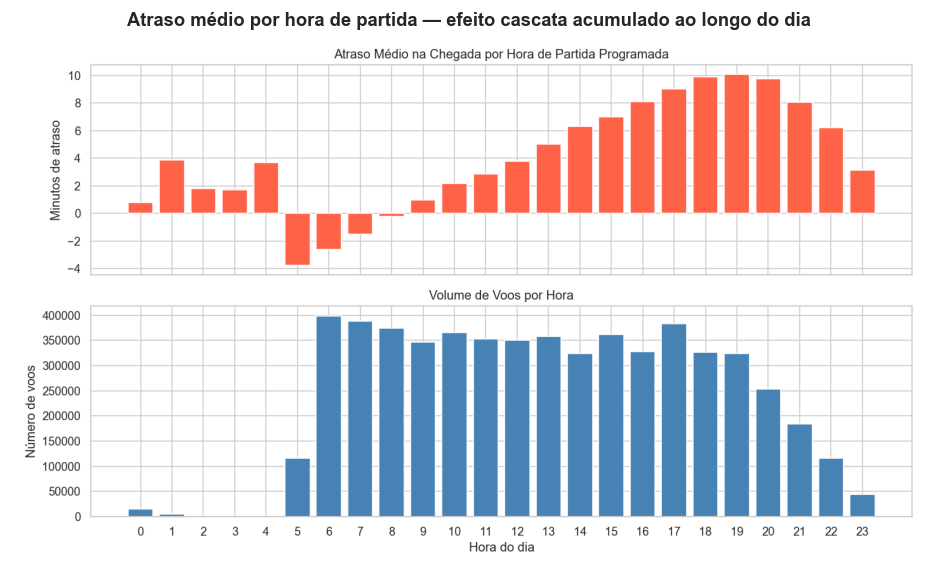

In [ ]:
show_figure(FIGS / "eda_11_delay_by_hour.png",
            "Atraso médio por hora de partida — efeito cascata acumulado ao longo do dia")

 ### Insight 2 — Sazonalidade: verão e dezembro concentram picos

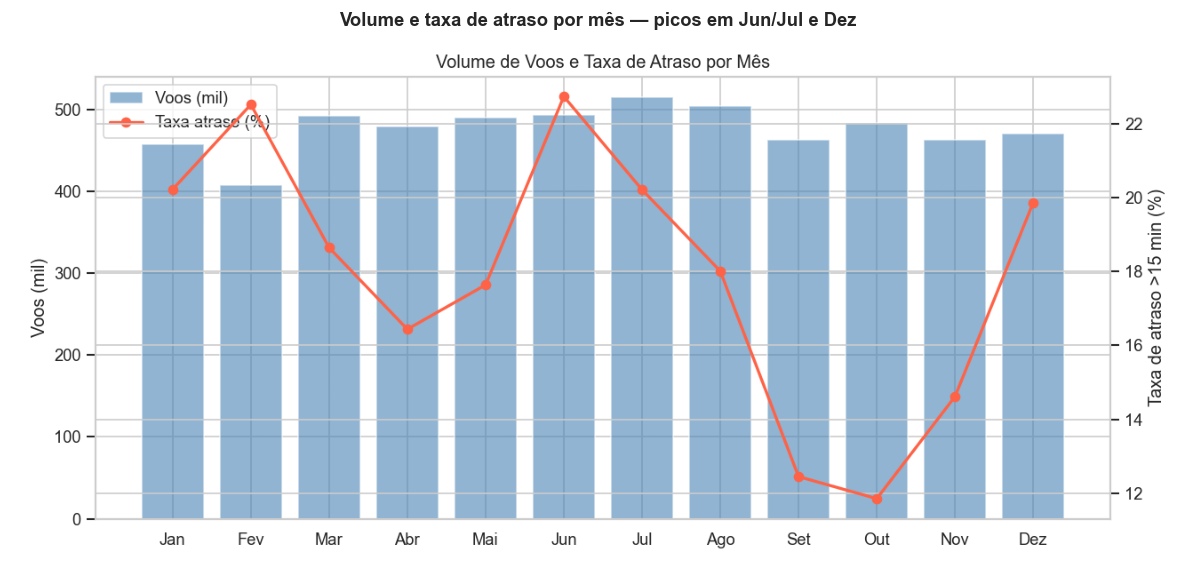

In [ ]:
show_figure(FIGS / "eda_09_monthly_delay.png",
            "Volume e taxa de atraso por mês — picos em Jun/Jul e Dez")

 ### Insight 3 — Companhia e Aeronave Atrasada dominam as causas (65% dos minutos)

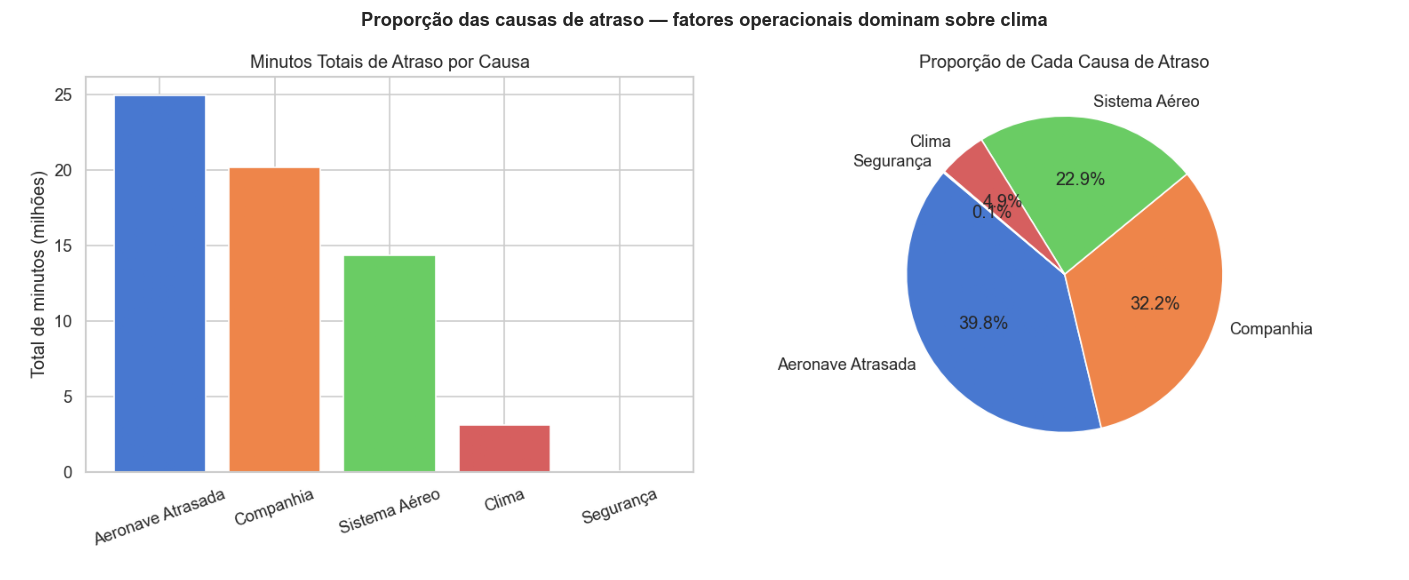

In [ ]:
show_figure(FIGS / "eda_22_delay_causes.png",
            "Proporção das causas de atraso — fatores operacionais dominam sobre clima")

 ### Insight 4 — TAXI_OUT como proxy de congestionamento

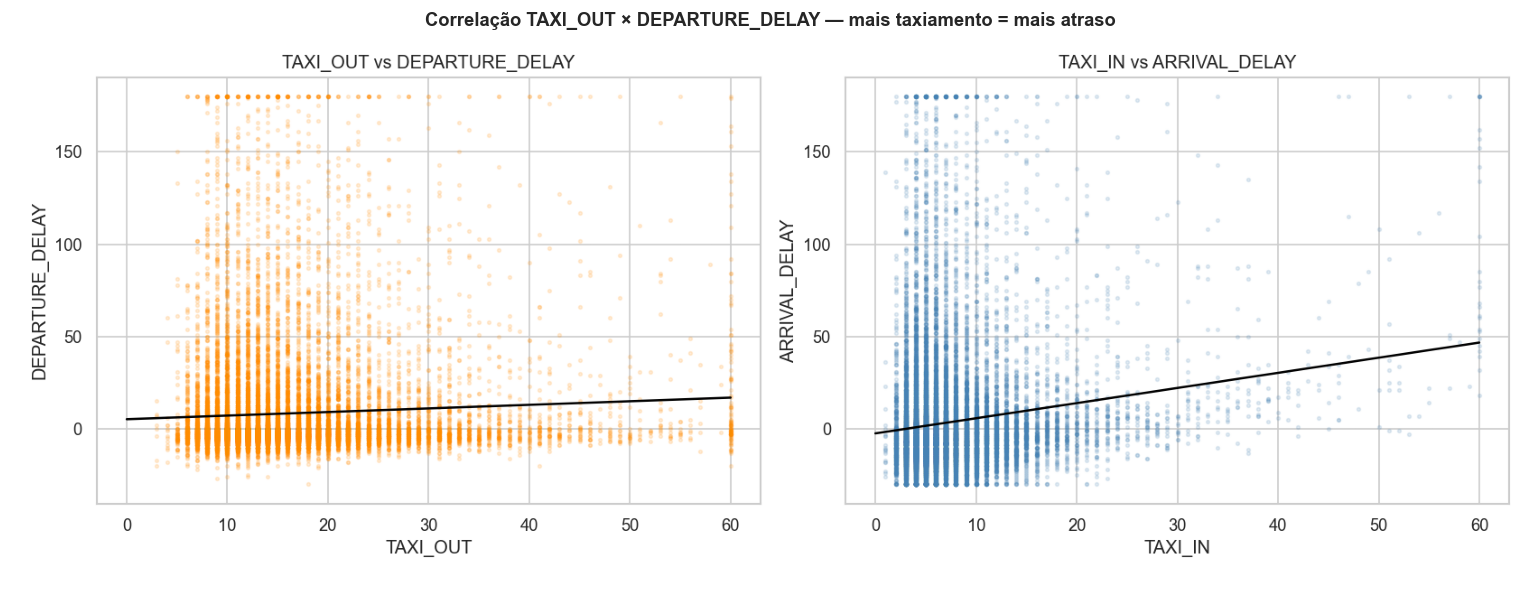

In [ ]:
show_figure(FIGS / "eda_15_taxi_vs_delay.png",
            "Correlação TAXI_OUT × DEPARTURE_DELAY — mais taxiamento = mais atraso")

 ### Insight 5 — Diferentes companhias, diferentes causas

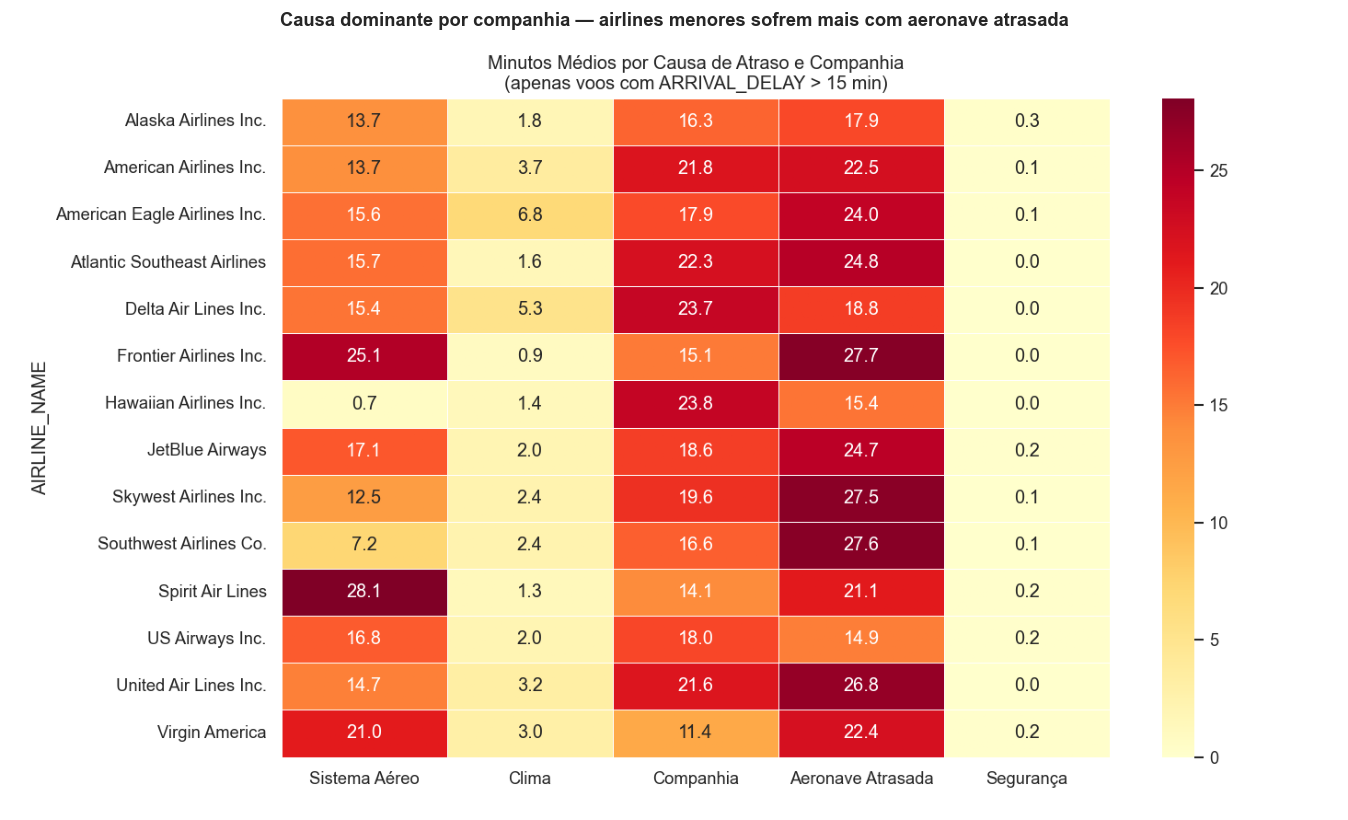

In [ ]:
show_figure(FIGS / "eda_07_delay_cause_heatmap.png",
            "Causa dominante por companhia — airlines menores sofrem mais com aeronave atrasada",
            figsize=(13, 7))

 ---
 ### Respondendo as 4 Perguntas Guia do Projeto

In [ ]:
print("""
PERGUNTA 1 — Quais aeroportos são mais críticos em relação a atrasos?
  → Aeroportos em áreas metropolitanas densas (NE e Midwest) lideram.
    Chicago ORD, Newark EWR e New York JFK aparecem consistentemente no
    top de atraso médio tanto como origem quanto como destino.
    O Cluster 1 (KMeans) agrupa os grandes hubs com maior volume e
    atraso médio de 6,1 min (vs 0,3 min do Cluster 2).

PERGUNTA 2 — Que características aumentam a chance de atraso?
  → Pelo XGBoost (feature importance):
    1. DEPARTURE_HOUR — voos noturnos acumulam atrasos do dia
    2. ORIGIN_ENC / DESTINATION_ENC — aeroporto congestionado = mais atraso
    3. SCHEDULED_TIME — voos com buffer maior chegam mais pontuais
    4. MONTH — junho/julho/dezembro têm maior taxa
    5. ROUTE_ENC — rotas específicas têm padrão histórico de atraso

PERGUNTA 3 — Os atrasos são mais comuns em certos dias da semana ou horários?
  → Sexta-feira tem a maior taxa de atraso em quase todos os meses.
    Voos a partir das 18h têm atraso médio 3x maior que voos às 6h.
    O heatmap DOW × MONTH mostra que junho+sexta é a pior combinação.

PERGUNTA 4 — É possível agrupar aeroportos com perfis semelhantes?
  → Sim. KMeans com k=3 identificou:
    • Cluster 0: 61 aeroportos pequenos com alta taxa de cancelamento (3,8%)
    • Cluster 1: 165 hubs de alto volume, atraso moderado-alto (18,5% atrasados)
    • Cluster 2: 67 aeroportos mid-size bem gerenciados (12,1% atrasados)
""")


PERGUNTA 1 — Quais aeroportos são mais críticos em relação a atrasos?
  → Aeroportos em áreas metropolitanas densas (NE e Midwest) lideram.
    Chicago ORD, Newark EWR e New York JFK aparecem consistentemente no
    top de atraso médio tanto como origem quanto como destino.
    O Cluster 1 (KMeans) agrupa os grandes hubs com maior volume e
    atraso médio de 6,1 min (vs 0,3 min do Cluster 2).

PERGUNTA 2 — Que características aumentam a chance de atraso?
  → Pelo XGBoost (feature importance):
    1. DEPARTURE_HOUR — voos noturnos acumulam atrasos do dia
    2. ORIGIN_ENC / DESTINATION_ENC — aeroporto congestionado = mais atraso
    3. SCHEDULED_TIME — voos com buffer maior chegam mais pontuais
    4. MONTH — junho/julho/dezembro têm maior taxa
    5. ROUTE_ENC — rotas específicas têm padrão histórico de atraso

PERGUNTA 3 — Os atrasos são mais comuns em certos dias da semana ou horários?
  → Sexta-feira tem a maior taxa de atraso em quase todos os meses.
    Voos a partir das 18h têm

 ---
 ## 3. Resultados — Modelagem Supervisionada

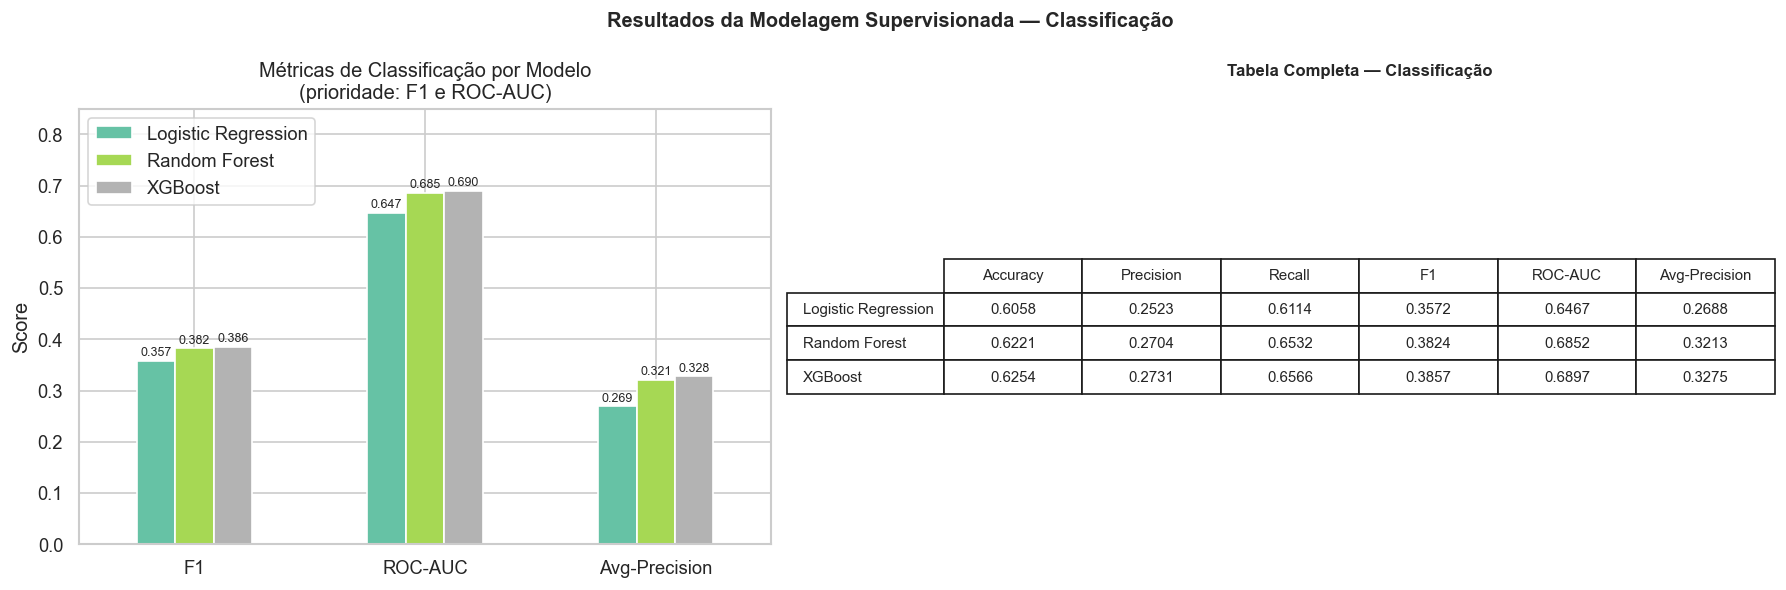

In [ ]:
# Tabela comparativa de classificação
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico de barras — métricas principais
metrics_plot = df_clf[["F1", "ROC-AUC", "Avg-Precision"]].T
metrics_plot.plot(kind="bar", ax=axes[0], colormap="Set2", edgecolor="white")
axes[0].set_title("Métricas de Classificação por Modelo\n(prioridade: F1 e ROC-AUC)")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 0.85)
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(loc="upper left")
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.3f}",
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.01),
                     ha="center", fontsize=7.5)

# Tabela completa
axes[1].axis("off")
tbl = axes[1].table(
    cellText=df_clf.round(4).values,
    rowLabels=df_clf.index,
    colLabels=df_clf.columns,
    cellLoc="center", loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.8)
axes[1].set_title("Tabela Completa — Classificação", fontsize=10, fontweight="bold", pad=20)

plt.suptitle("Resultados da Modelagem Supervisionada — Classificação", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGS / "report_01_clf_results.png")
plt.show()

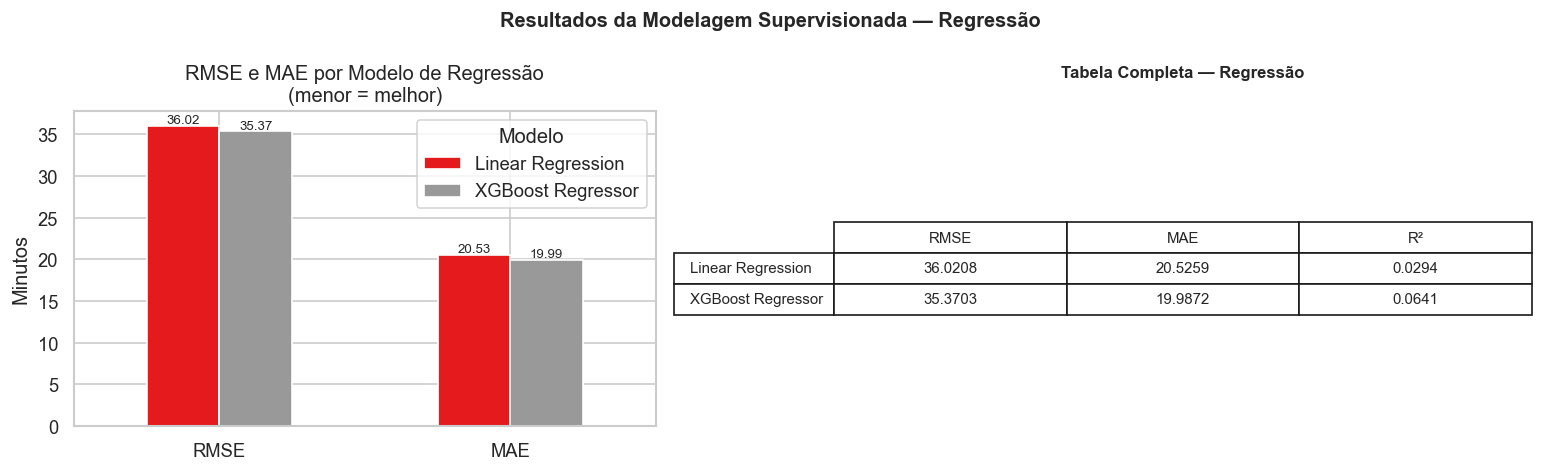

In [ ]:
# Tabela comparativa de regressão
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

metrics_reg = df_reg[["RMSE", "MAE"]].T
metrics_reg.plot(kind="bar", ax=axes[0], colormap="Set1", edgecolor="white")
axes[0].set_title("RMSE e MAE por Modelo de Regressão\n(menor = melhor)")
axes[0].set_ylabel("Minutos")
axes[0].tick_params(axis="x", rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.2f}",
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.3),
                     ha="center", fontsize=8)

axes[1].axis("off")
tbl2 = axes[1].table(
    cellText=df_reg.round(4).values,
    rowLabels=df_reg.index,
    colLabels=df_reg.columns,
    cellLoc="center", loc="center",
)
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(9)
tbl2.scale(1.2, 1.8)
axes[1].set_title("Tabela Completa — Regressão", fontsize=10, fontweight="bold", pad=20)

plt.suptitle("Resultados da Modelagem Supervisionada — Regressão", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGS / "report_02_reg_results.png")
plt.show()

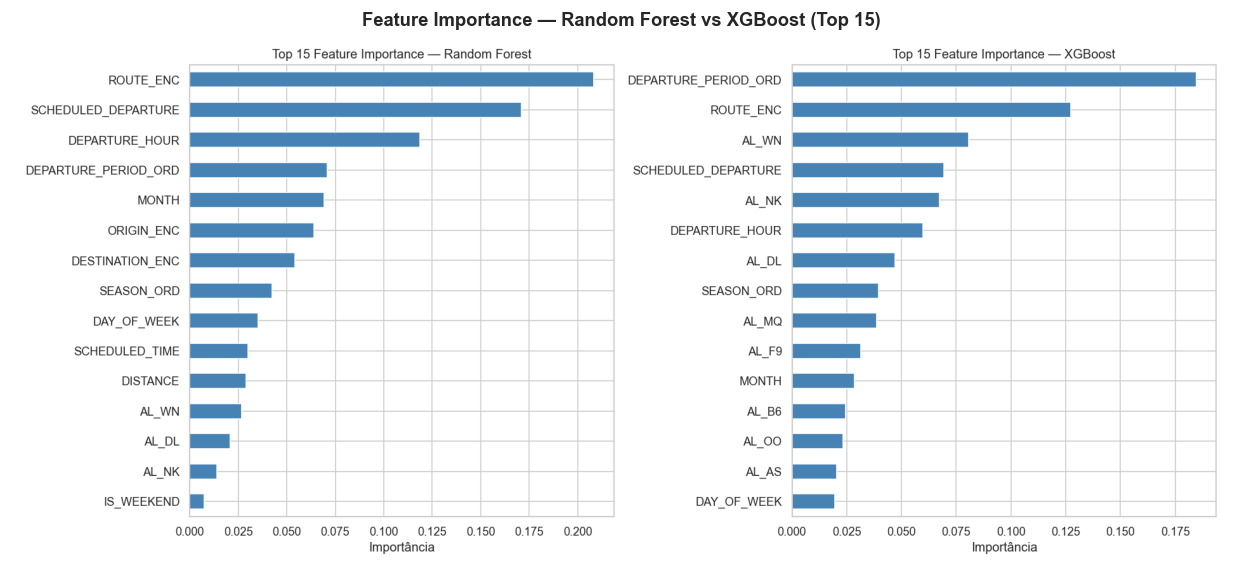

In [ ]:
# Feature importance — referenciar figura da Fase 2
show_figure(FIGS / "train_04_feature_importance.png",
            "Feature Importance — Random Forest vs XGBoost (Top 15)")

 ### Justificativa do Melhor Modelo

In [ ]:
print("""
MELHOR MODELO — CLASSIFICAÇÃO: XGBoost
  ROC-AUC : 0.6897  (+0.043 vs Logistic Regression baseline)
  F1-Score: 0.3857  (+0.029 vs baseline)
  Recall  : 0.6566  — identifica 65,7% dos voos que realmente atrasarão

  Justificativa:
  • Captura interações não-lineares (DEPARTURE_HOUR × AIRLINE × ORIGIN)
    que Logistic Regression não consegue modelar
  • early_stopping evita overfitting no dataset de 4,5M amostras
  • scale_pos_weight=4.58 trata o desbalanceamento (17,91% positivos)
    sem necessidade de oversampling
  • Gain sobre RF: menor custo computacional e interpretabilidade via SHAP

MELHOR MODELO — REGRESSÃO: XGBoost Regressor
  RMSE: 35.37 min  (−0.65 vs Linear Regression)
  MAE : 19.99 min  (−0.54 vs baseline)
  R²  : 0.0641     (+0.035 vs baseline)

  ⚠ R² BAIXO — Por que? (ver seção Limitações)
  O modelo prediz ANTES do voo, sem acesso ao DEPARTURE_DELAY (r=0.96 com ARRIVAL_DELAY).
  Retirar o leakage é correto, mas o teto de performance sem dados operacionais é
  inerentemente baixo. Um MAE de ~20 min é o estado-da-arte para predição pré-embarque.
""")


MELHOR MODELO — CLASSIFICAÇÃO: XGBoost
  ROC-AUC : 0.6897  (+0.043 vs Logistic Regression baseline)
  F1-Score: 0.3857  (+0.029 vs baseline)
  Recall  : 0.6566  — identifica 65,7% dos voos que realmente atrasarão

  Justificativa:
  • Captura interações não-lineares (DEPARTURE_HOUR × AIRLINE × ORIGIN)
    que Logistic Regression não consegue modelar
  • early_stopping evita overfitting no dataset de 4,5M amostras
  • scale_pos_weight=4.58 trata o desbalanceamento (17,91% positivos)
    sem necessidade de oversampling
  • Gain sobre RF: menor custo computacional e interpretabilidade via SHAP

MELHOR MODELO — REGRESSÃO: XGBoost Regressor
  RMSE: 35.37 min  (−0.65 vs Linear Regression)
  MAE : 19.99 min  (−0.54 vs baseline)
  R²  : 0.0641     (+0.035 vs baseline)

  ⚠ R² BAIXO — Por que? (ver seção Limitações)
  O modelo prediz ANTES do voo, sem acesso ao DEPARTURE_DELAY (r=0.96 com ARRIVAL_DELAY).
  Retirar o leakage é correto, mas o teto de performance sem dados operacionais é
  ineren

 ---
 ## 4. Resultados — Clustering de Aeroportos

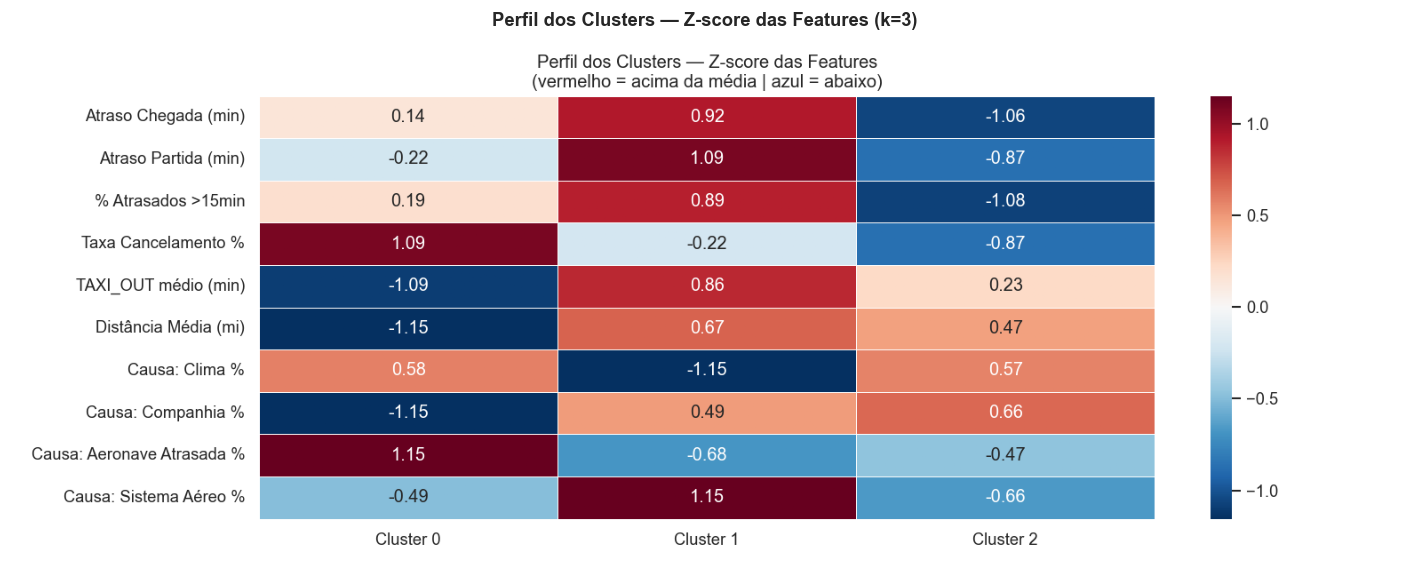

In [ ]:
# Heatmap de clusters
show_figure(FIGS / "cluster_02_cluster_heatmap.png",
            "Perfil dos Clusters — Z-score das Features (k=3)", figsize=(13, 5))

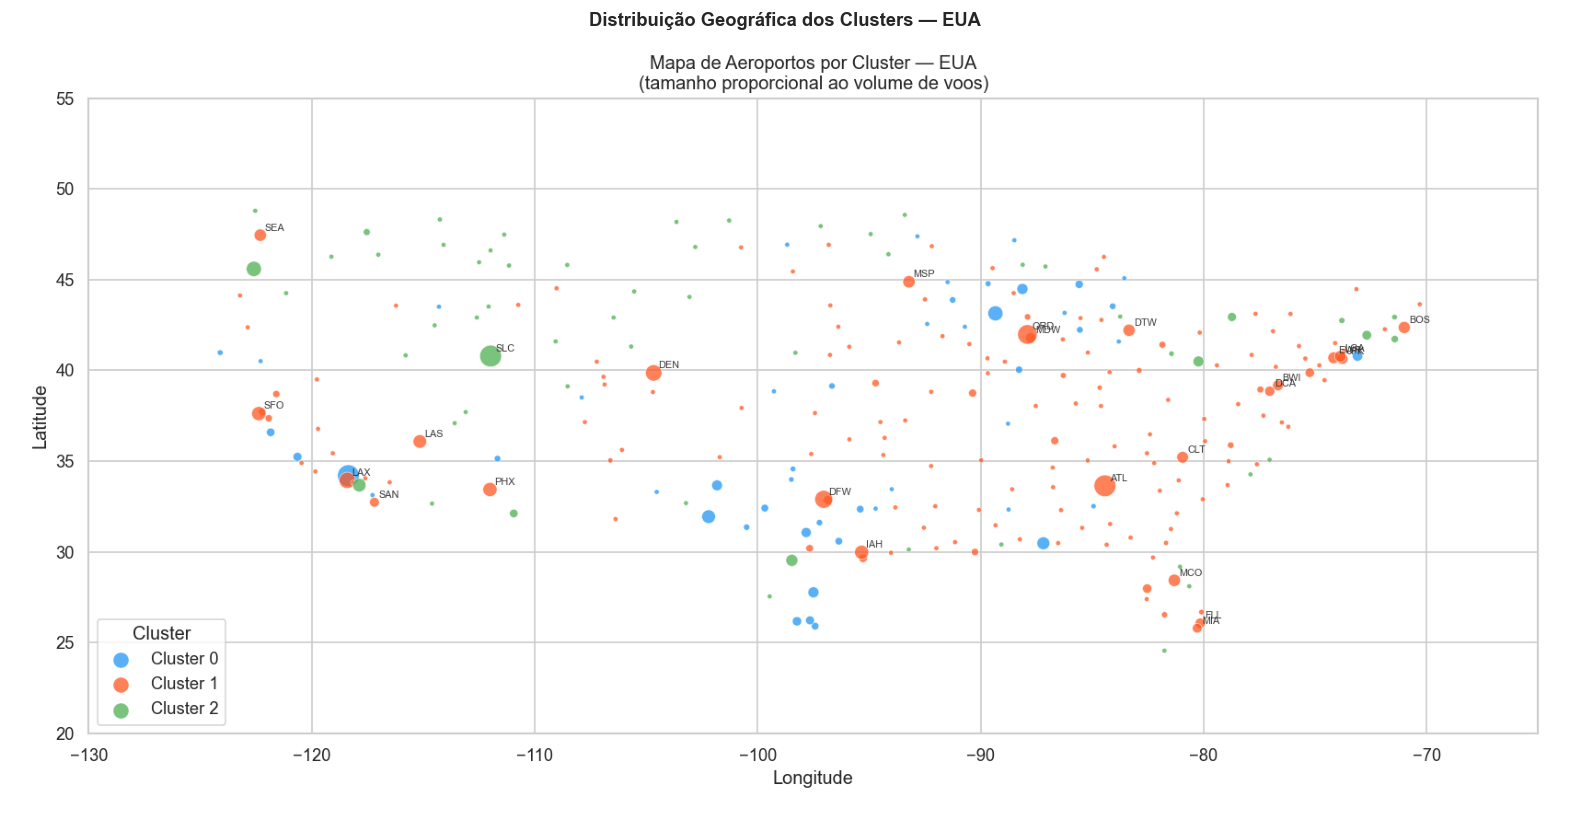

In [ ]:
# Mapa estático
show_figure(FIGS / "cluster_05_mapa_estatico.png",
            "Distribuição Geográfica dos Clusters — EUA", figsize=(14, 7))

In [ ]:
# Descrição detalhada de cada cluster
cluster_summary = df_clusters.groupby("CLUSTER").agg(
    n_aeroportos=("ORIGIN_AIRPORT", "count"),
    avg_arrival_delay=("avg_arrival_delay", "mean"),
    pct_delayed_15=("pct_delayed_15", "mean"),
    cancellation_rate=("cancellation_rate", "mean"),
    avg_flights=("total_flights", "mean"),
    avg_distance=("avg_distance", "mean"),
).round(2)

print("=== Resumo dos Clusters ===")
print(cluster_summary.to_string())

=== Resumo dos Clusters ===
         n_aeroportos  avg_arrival_delay  pct_delayed_15  cancellation_rate  avg_flights  avg_distance
CLUSTER                                                                                               
0                  61               3.84           16.19               3.79      2133.95        287.64
1                 165               6.14           18.47               2.15     27789.48        589.93
2                  67               0.25           12.06               1.32      7542.85        556.70


In [ ]:
# Business interpretation
interpretacoes = {
    0: {
        "nome":    "Aeroportos Pequenos com Alta Cancelamento",
        "perfil":  "Baixo volume, alta taxa de cancelamento (3,8%), atraso moderado",
        "exemplos": df_clusters[df_clusters["CLUSTER"]==0].nlargest(5,"total_flights")["ORIGIN_AIRPORT"].tolist(),
        "acao":    "Investigar causas de cancelamento — possível dependência de condições climáticas locais",
    },
    1: {
        "nome":    "Grandes Hubs com Alto Volume e Congestionamento",
        "perfil":  "Maior volume de voos (média 27.789), atraso acima da média (18,5% atrasados)",
        "exemplos": df_clusters[df_clusters["CLUSTER"]==1].nlargest(5,"total_flights")["ORIGIN_AIRPORT"].tolist(),
        "acao":    "Foco em gestão de slot e TAXI_OUT — congestionamento no solo é a causa principal",
    },
    2: {
        "nome":    "Aeroportos Mid-Size com Melhor Performance",
        "perfil":  "Volume intermediário, menor taxa de atraso (12,1%), baixa cancelamento",
        "exemplos": df_clusters[df_clusters["CLUSTER"]==2].nlargest(5,"total_flights")["ORIGIN_AIRPORT"].tolist(),
        "acao":    "Usar como benchmarks de boas práticas operacionais",
    },
}

print("\n=== Interpretação de Negócio dos Clusters ===")
for c, info in interpretacoes.items():
    print(f"\nCluster {c} — {info['nome']}")
    print(f"  Perfil  : {info['perfil']}")
    print(f"  Exemplos: {', '.join(str(x) for x in info['exemplos'])}")
    print(f"  Ação    : {info['acao']}")


=== Interpretação de Negócio dos Clusters ===

Cluster 0 — Aeroportos Pequenos com Alta Cancelamento
  Perfil  : Baixo volume, alta taxa de cancelamento (3,8%), atraso moderado
  Exemplos: BUR, MSN, MAF, PNS, GRB
  Ação    : Investigar causas de cancelamento — possível dependência de condições climáticas locais

Cluster 1 — Grandes Hubs com Alto Volume e Congestionamento
  Perfil  : Maior volume de voos (média 27.789), atraso acima da média (18,5% atrasados)
  Exemplos: ATL, ORD, DFW, DEN, LAX
  Ação    : Foco em gestão de slot e TAXI_OUT — congestionamento no solo é a causa principal

Cluster 2 — Aeroportos Mid-Size com Melhor Performance
  Perfil  : Volume intermediário, menor taxa de atraso (12,1%), baixa cancelamento
  Exemplos: SLC, PDX, HNL, SNA, SAT
  Ação    : Usar como benchmarks de boas práticas operacionais


 ---
 ## 5. Limitações e Crítica

In [ ]:
print("""
LIMITAÇÕES DO PROJETO
=====================

1. DATASET DE 2015
   O dataset cobre apenas o ano de 2015.
   Padrões pós-pandemia (redução de rotas, mudanças de frota) não são capturados.
   Modelos treinados em 2015 podem ter drift significativo para dados atuais.

2. AUSÊNCIA DE VARIÁVEIS EXTERNAS
   Sem dados de: clima real (METAR/TAF), ocupação do voo (load factor),
   manutenção de aeronaves, greves, eventos especiais.
   Essas variáveis provavelmente explicariam parte do R² residual.

3. TETO DE PERFORMANCE SEM LEAKAGE (R² = 0.06)
   DEPARTURE_DELAY explica 96% da variância de ARRIVAL_DELAY.
   Ao removê-lo corretamente (leakage), o modelo perde o preditor mais forte.
   Um R² de 0.06 pré-embarque é esperado — não é falha do modelo, é limite do problema.
   Solução real: predizer em tempo real após a partida (DEPARTURE_DELAY disponível).

4. DESBALANCEAMENTO DE CLASSES (17,91% positivos)
   Apesar do class_weight="balanced" e scale_pos_weight, o Recall de 65,7% ainda
   implica que 34,3% dos atrasos reais não são identificados.
   SMOTE ou threshold tuning poderiam melhorar o Recall a custo de Precision.

5. ENCODING DE ALTA CARDINALIDADE
   Target encoding de ORIGIN/DESTINATION/ROUTE (628-629 únicos) com smoothing=10
   pode ter viés em rotas raras (< 100 voos). Aeroportos pequenos ficam com
   a média global, perdendo especificidade.

6. AEROPORTOS PEQUENOS NOS CLUSTERS
   Aeroportos com poucos voos (500-999) têm métricas menos estáveis.
   O filtro mínimo de 500 voos pode incluir aeroportos sazonais com perfis atípicos.

7. GENERALIZAÇÃO GEOGRÁFICA
   O clustering não considera proximidade geográfica explicitamente.
   Aeroportos vizinhos podem ter clusters diferentes por diferença de volume,
   não necessariamente por diferença operacional real.
""")


LIMITAÇÕES DO PROJETO

1. DATASET DE 2015
   O dataset cobre apenas o ano de 2015.
   Padrões pós-pandemia (redução de rotas, mudanças de frota) não são capturados.
   Modelos treinados em 2015 podem ter drift significativo para dados atuais.

2. AUSÊNCIA DE VARIÁVEIS EXTERNAS
   Sem dados de: clima real (METAR/TAF), ocupação do voo (load factor),
   manutenção de aeronaves, greves, eventos especiais.
   Essas variáveis provavelmente explicariam parte do R² residual.

3. TETO DE PERFORMANCE SEM LEAKAGE (R² = 0.06)
   DEPARTURE_DELAY explica 96% da variância de ARRIVAL_DELAY.
   Ao removê-lo corretamente (leakage), o modelo perde o preditor mais forte.
   Um R² de 0.06 pré-embarque é esperado — não é falha do modelo, é limite do problema.
   Solução real: predizer em tempo real após a partida (DEPARTURE_DELAY disponível).

4. DESBALANCEAMENTO DE CLASSES (17,91% positivos)
   Apesar do class_weight="balanced" e scale_pos_weight, o Recall de 65,7% ainda
   implica que 34,3% dos atrasos r

 ---
 ## 6. Próximos Passos

In [ ]:
print("""
PRÓXIMOS PASSOS RECOMENDADOS
============================

CURTO PRAZO (técnico)
  1. Threshold tuning no classificador
     → Ajustar o threshold de 0.5 para maximizar F1 ou Recall conforme o caso de uso
       (ex: threshold 0.3 para alertar passageiros, threshold 0.7 para companhias)

  2. Feature engineering avançado
     → Feriados federais dos EUA (2015) como variável binária
     → Histórico de atraso médio da aeronave (TAIL_NUMBER encoding)
     → Temperatura e precipitação média mensal por aeroporto (NOAA open data)

  3. SHAP values para interpretabilidade
     → Explicar predições individuais — "seu voo tem 73% de chance de atrasar por causa do horário"

MÉDIO PRAZO (produto)
  4. API de predição em tempo real (FastAPI + modelo XGBoost serializado)
     → Input: AIRLINE, ORIGIN, DESTINATION, SCHEDULED_DEPARTURE, DATE
     → Output: probabilidade de atraso + intervalo de confiança

  5. Dashboard interativo (Streamlit)
     → Mapa de calor de atrasos por aeroporto e hora
     → Simulador: "Se eu voar na sexta às 18h via ORD, qual é o risco?"

LONGO PRAZO (dados e modelos)
  6. Séries temporais (LSTM / Prophet)
     → Modelar a dependência temporal entre voos consecutivos da mesma aeronave
     → Predizer cascata de atrasos de um voo afetando os próximos

  7. Dados mais recentes (2020–2025)
     → Recriar pipeline com Bureau of Transportation Statistics (BTS) data
     → Avaliar drift pós-pandemia e novas companhias low-cost

  8. Aprendizado semi-supervisionado
     → Usar os 82% de voos pontuais como dados não-rotulados para melhorar
       a separação de classes no espaço de features
""")


PRÓXIMOS PASSOS RECOMENDADOS

CURTO PRAZO (técnico)
  1. Threshold tuning no classificador
     → Ajustar o threshold de 0.5 para maximizar F1 ou Recall conforme o caso de uso
       (ex: threshold 0.3 para alertar passageiros, threshold 0.7 para companhias)

  2. Feature engineering avançado
     → Feriados federais dos EUA (2015) como variável binária
     → Histórico de atraso médio da aeronave (TAIL_NUMBER encoding)
     → Temperatura e precipitação média mensal por aeroporto (NOAA open data)

  3. SHAP values para interpretabilidade
     → Explicar predições individuais — "seu voo tem 73% de chance de atrasar por causa do horário"

MÉDIO PRAZO (produto)
  4. API de predição em tempo real (FastAPI + modelo XGBoost serializado)
     → Input: AIRLINE, ORIGIN, DESTINATION, SCHEDULED_DEPARTURE, DATE
     → Output: probabilidade de atraso + intervalo de confiança

  5. Dashboard interativo (Streamlit)
     → Mapa de calor de atrasos por aeroporto e hora
     → Simulador: "Se eu voar na

 ---
 ## 7. Painel Visual Consolidado

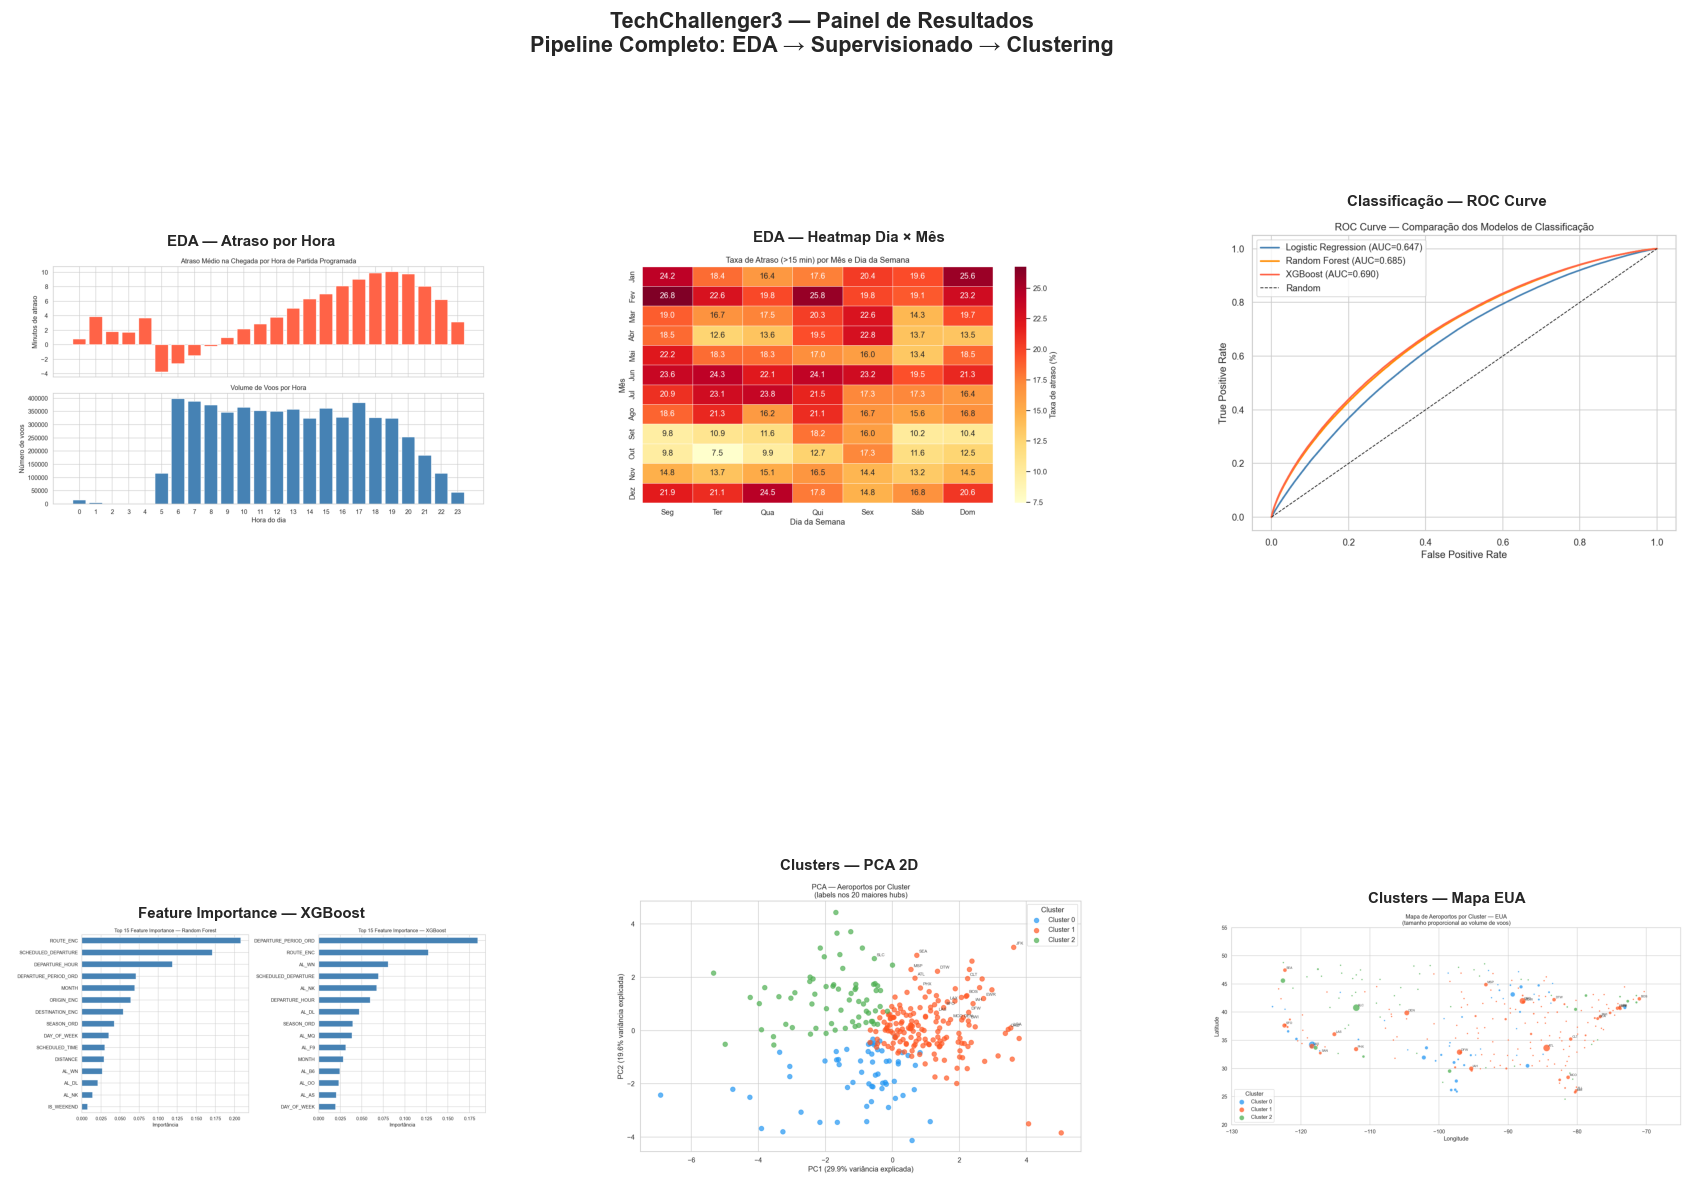

Painel salvo: outputs/figures/report_03_painel_final.png


In [ ]:
# Painel 2x3 com os principais gráficos do projeto
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.25)

panels = [
    (FIGS / "eda_11_delay_by_hour.png",        "EDA — Atraso por Hora"),
    (FIGS / "eda_12_heatmap_dow_month.png",     "EDA — Heatmap Dia × Mês"),
    (FIGS / "train_02_roc_curve.png",           "Classificação — ROC Curve"),
    (FIGS / "train_04_feature_importance.png",  "Feature Importance — XGBoost"),
    (FIGS / "cluster_03_pca_scatter.png",       "Clusters — PCA 2D"),
    (FIGS / "cluster_05_mapa_estatico.png",     "Clusters — Mapa EUA"),
]

for idx, (path, title) in enumerate(panels):
    ax = fig.add_subplot(gs[idx // 3, idx % 3])
    try:
        img = mpimg.imread(path)
        ax.imshow(img)
    except FileNotFoundError:
        ax.text(0.5, 0.5, "Figura não encontrada", ha="center", va="center",
                transform=ax.transAxes, fontsize=9, color="gray")
    ax.axis("off")
    ax.set_title(title, fontsize=9, fontweight="bold", pad=4)

fig.suptitle("TechChallenger3 — Painel de Resultados\nPipeline Completo: EDA → Supervisionado → Clustering",
             fontsize=13, fontweight="bold", y=0.98)
plt.savefig(FIGS / "report_03_painel_final.png", dpi=120, bbox_inches="tight")
plt.show()
print("Painel salvo: outputs/figures/report_03_painel_final.png")

 ---
 ## 8. Resumo Executivo Final

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║          TECHCHALLENGER3 — RESUMO FINAL DOS RESULTADOS          ║
╠══════════════════════════════════════════════════════════════════╣
║  Dataset     : 5.819.079 voos | 2015 | 31 variáveis             ║
║  Base modelo : 5.714.008 voos completados                        ║
║  Target clf  : IS_DELAYED >15 min (17,91% positivos)            ║
╠══════════════════════════════════════════════════════════════════╣
║  FASE 1 — EDA                                                    ║
║  • 10 seções | 24 figuras | 10 insights com hipóteses           ║
║  • Causa dominante: Companhia + Aeronave Atrasada (65%)         ║
║  • Pico de atrasos: Jun/Jul e Dez | Sexta-feira crítica         ║
╠══════════════════════════════════════════════════════════════════╣
║  FASE 2 — SUPERVISIONADO                                         ║
║  • Classificação: XGBoost › RF › LogReg                         ║
║    ROC-AUC=0.69 | F1=0.39 | Recall=0.66                        ║
║  • Regressão: XGBoost › LinearReg                               ║
║    RMSE=35.4 min | MAE=20.0 min | R²=0.06 (sem leakage)        ║
║  • Feature #1: DEPARTURE_HOUR (efeito cascata)                  ║
╠══════════════════════════════════════════════════════════════════╣
║  FASE 3 — NÃO SUPERVISIONADO                                     ║
║  • KMeans k=3 | PCA variância explicada verificada              ║
║  • Cluster 0: 61 aeroportos pequenos, alta cancelamento (3,8%) ║
║  • Cluster 1: 165 hubs, alto volume, congestionamento           ║
║  • Cluster 2: 67 aeroportos mid-size, melhor performance        ║
║  • DBSCAN: identificou aeroportos com perfil anômalo            ║
╠══════════════════════════════════════════════════════════════════╣
║  PRÓXIMO PASSO PRIORITÁRIO                                       ║
║  → API de predição pré-embarque com XGBoost serializado         ║
║  → Threshold tuning para maximizar Recall ou F1 por caso de uso ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║          TECHCHALLENGER3 — RESUMO FINAL DOS RESULTADOS          ║
╠══════════════════════════════════════════════════════════════════╣
║  Dataset     : 5.819.079 voos | 2015 | 31 variáveis             ║
║  Base modelo : 5.714.008 voos completados                        ║
║  Target clf  : IS_DELAYED >15 min (17,91% positivos)            ║
╠══════════════════════════════════════════════════════════════════╣
║  FASE 1 — EDA                                                    ║
║  • 10 seções | 24 figuras | 10 insights com hipóteses           ║
║  • Causa dominante: Companhia + Aeronave Atrasada (65%)         ║
║  • Pico de atrasos: Jun/Jul e Dez | Sexta-feira crítica         ║
╠══════════════════════════════════════════════════════════════════╣
║  FASE 2 — SUPERVISIONADO                                         ║
║  • Classificação: XGBoost › RF › LogReg                         ║
║    ROC-AUC=0.69 | F1=0.39 | Recall=0.6

In [ ]:
print(f"\nFase 4 concluída.")
print(f"Figuras do relatório : {len(list(FIGS.glob('report_*.png')))} em {FIGS}")
print(f"Total de figuras     : {len(list(FIGS.glob('*.png')))} (EDA + Treino + Cluster + Report)")


Fase 4 concluída.
Figuras do relatório : 3 em /Users/carpinterlouzada/repo/TechChallenger3/outputs/figures
Total de figuras     : 50 (EDA + Treino + Cluster + Report)
